In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/mlt/preprocessing_dataset.csv')
df.head()

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,NaN,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT


In [ ]:
df1=df.copy()
df2=df.copy()
df3=df.copy()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        10 non-null     object 
 1   Age         9 non-null      float64
 2   Gender      9 non-null      object 
 3   Salary      9 non-null      float64
 4   Department  10 non-null     object 
dtypes: float64(2), object(3)
memory usage: 532.0+ bytes


In [ ]:
df.describe()

,Age,Salary
count,9.000000,9.000000
mean,39.555556,57777.777778
std,30.631320,4521.553322
min,22.000000,50000.000000
25%,27.000000,55000.000000
50%,29.000000,59000.000000
75%,35.000000,61000.000000
max,120.000000,63000.000000


In [ ]:
df.isna().sum()

,0
Name,0
Age,1
Gender,1
Salary,1
Department,0


In [ ]:
df.shape

(10, 5)

**MISSING VALUES**

<Axes: >

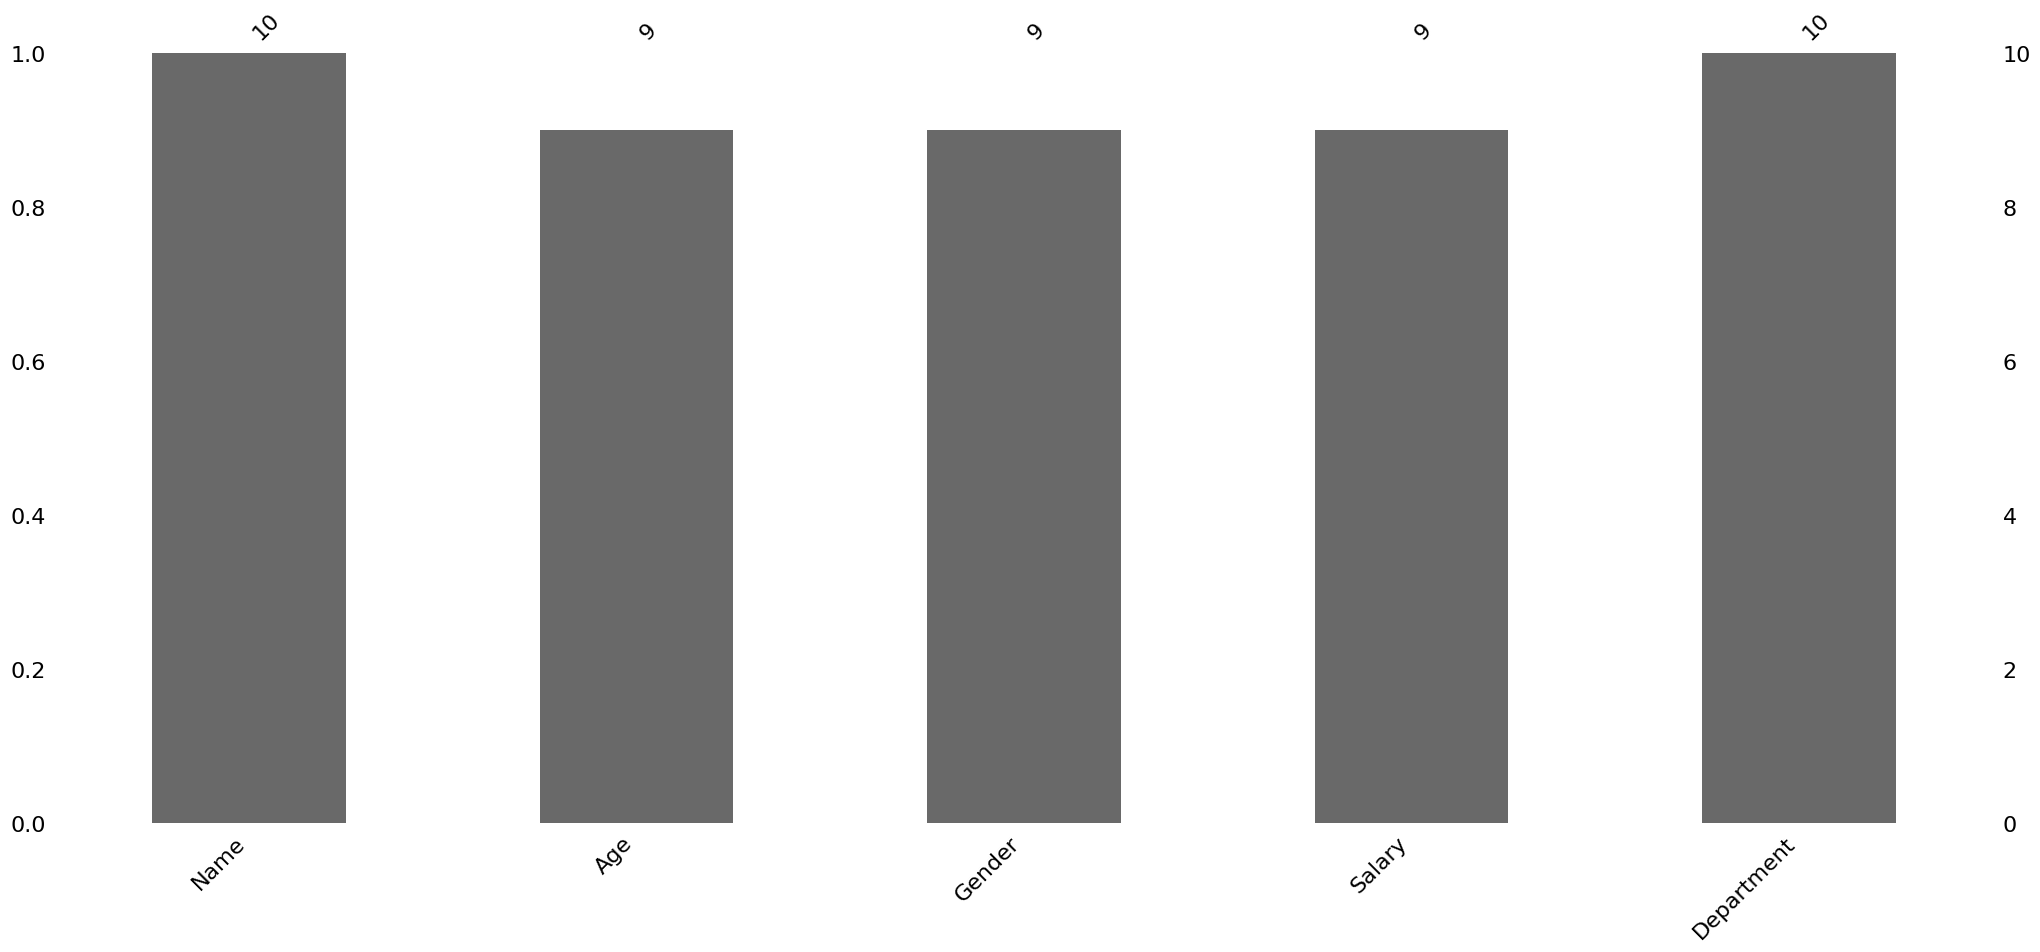

In [ ]:
!pip install missingno
import missingno as msno
msno.bar(df)

<Axes: >

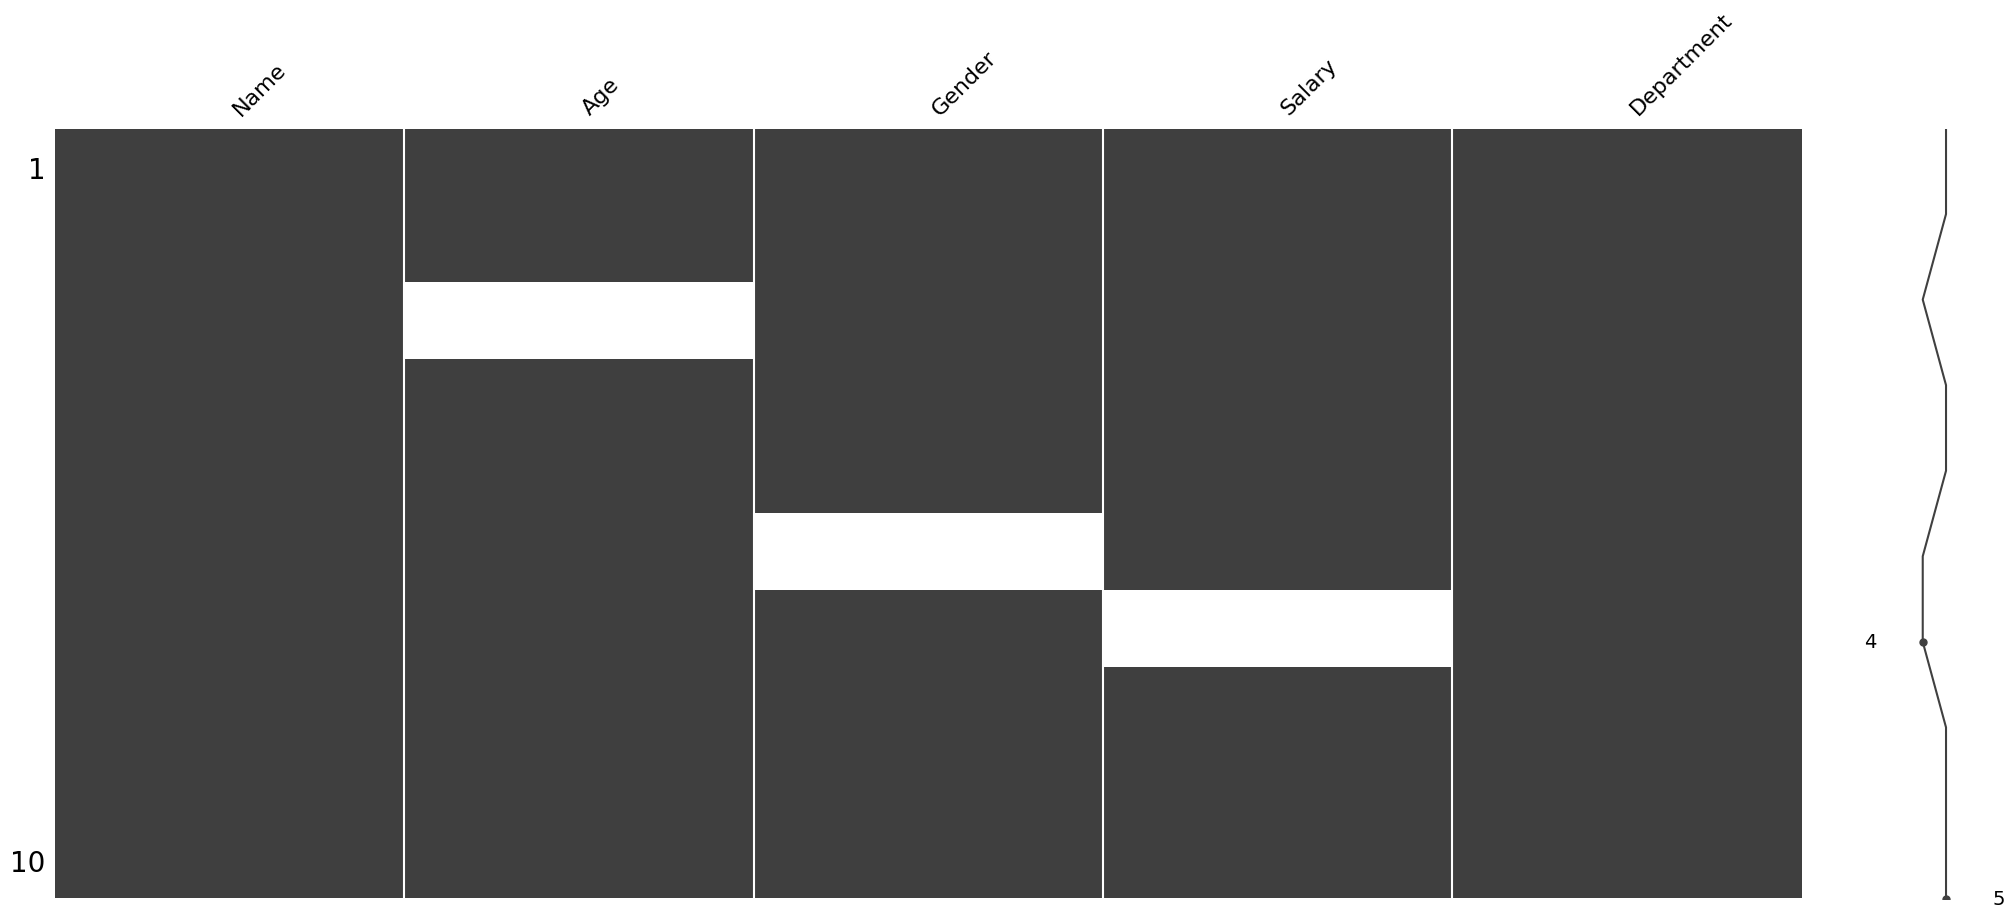

In [ ]:
msno.matrix(df)

<Axes: >

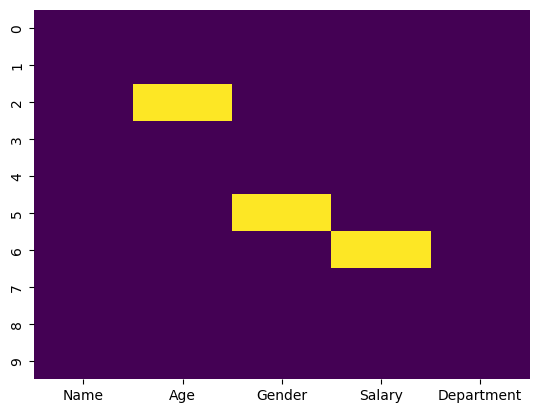

In [ ]:
sns.heatmap(df.isnull(),cbar=False,cmap='viridis')

**HANDLING MISSING VALUES**

1. fillna()
   --mean - continuous values - no outlier -    normal distribution
   --median - skewed data - discrete - outlier
   --mode - categorical



In [ ]:
df['Age'].fillna(df['Age'].mean(),inplace=True)
df['Salary'].fillna(df['Salary'].mean(),inplace=True)
df['Gender'].fillna(df['Gender'].mode()[0],inplace=True)

/tmp/ipykernel_3763/4103641573.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)
/tmp/ipykernel_3763/4103641573.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [ ]:
df.isnull().sum()

,0
Name,0
Age,0
Gender,0
Salary,0
Department,0


Simple imputer

In [ ]:
from sklearn.impute import SimpleImputer

imp=SimpleImputer(strategy='mean')
df1['Age']=imp.fit_transform(df1[['Age']])
df1['Salary']=imp.fit_transform(df1[['Salary']])
imp1=SimpleImputer(strategy='most_frequent')
df1[['Gender']]=imp1.fit_transform(df1[['Gender']])
df1


,Name,Age,Gender,Salary,Department
0,Alice,25.000000,F,50000.000000,HR
1,Bob,30.000000,M,60000.000000,Finance
2,Charlie,39.555556,M,55000.000000,IT
3,David,40.000000,M,58000.000000,HR
4,Eve,22.000000,F,52000.000000,IT
5,Frank,35.000000,M,61000.000000,Finance
6,Grace,120.000000,F,57777.777778,Finance
7,Henry,28.000000,M,59000.000000,HR
8,Ivy,29.000000,F,63000.000000,IT
9,Jack,27.000000,M,62000.000000,Finance


**OUTLIERS**

<Axes: ylabel='Age'>

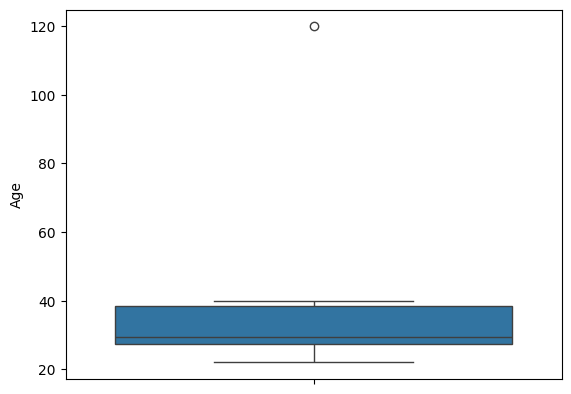

In [ ]:
sns.boxplot(df1['Age'])

In [ ]:
Q1=df['Age'].quantile(0.25)
Q3=df['Age'].quantile(0.75)
IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3 + 1.5*IQR
outliers=df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]
outliers

,Name,Age,Gender,Salary,Department
6,Grace,120.0,F,57777.777778,Finance


In [ ]:
from scipy.stats import zscore

z_scores = zscore(df['Age'])
df[np.abs(z_scores)>2.5]  #Common Rule: z>3 means outliers

,Name,Age,Gender,Salary,Department
6,Grace,120.0,F,57777.777778,Finance


In [ ]:
from sklearn.ensemble import IsolationForest

iso=IsolationForest(contamination=0.1)
df['outlier']=iso.fit_predict(df[['Age','Salary']])

df[df['outlier']==-1]

,Name,Age,Gender,Salary,Department,outlier
6,Grace,120.0,F,57777.777778,Finance,-1


**HANDLING OUTLIERS**

<Axes: ylabel='Age'>

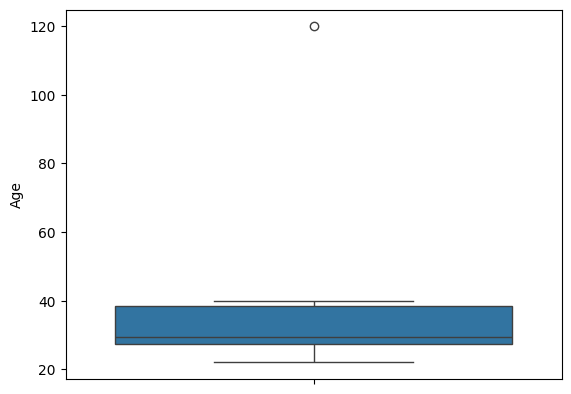

In [ ]:
sns.boxplot(df1['Age'])

<Axes: xlabel='Age', ylabel='Count'>

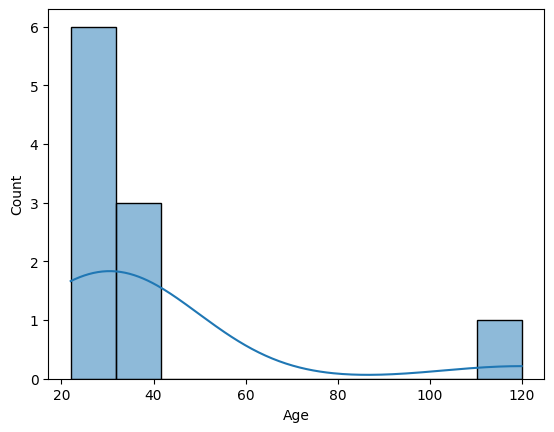

In [ ]:
sns.histplot(df1['Age'],kde=True)

<Axes: ylabel='winsorized'>

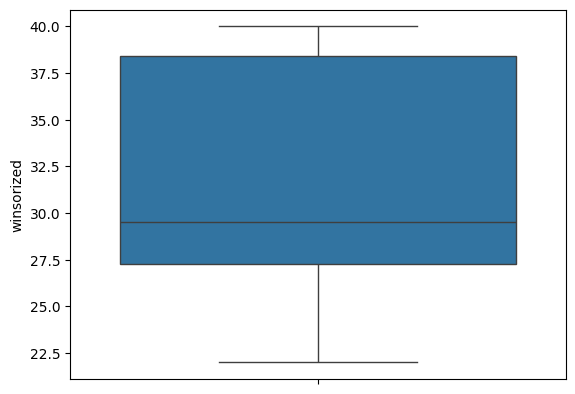

In [ ]:
from scipy.stats.mstats import winsorize

df['winsorized']=winsorize(df['Age'],limits=[0.01,0.1])  #Caps data to 5% to 90%(5 to 95 is normal)

sns.boxplot(df['winsorized'])

<Axes: xlabel='logged', ylabel='Count'>

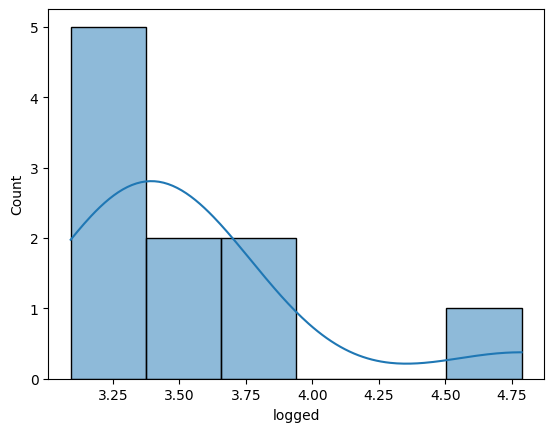

In [ ]:
df1['logged']=np.log(df1['Age'])

sns.histplot(df1['logged'],kde=True)


<Axes: xlabel='power', ylabel='Count'>

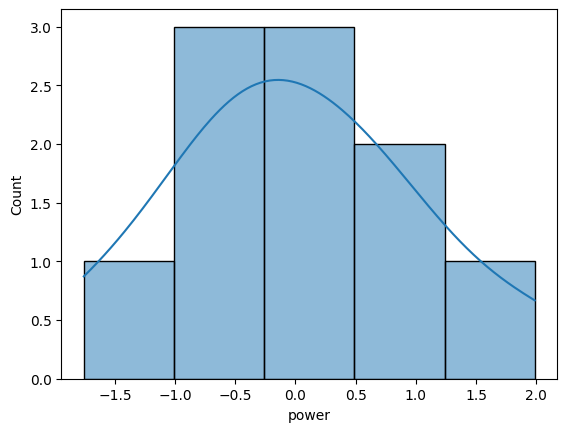

In [ ]:
from sklearn.preprocessing import PowerTransformer

pt=PowerTransformer(method='yeo-johnson')

df1['power']=pt.fit_transform(df1[['Age']])

sns.histplot(df1['power'],kde=True)

<Axes: xlabel='scaled', ylabel='Count'>

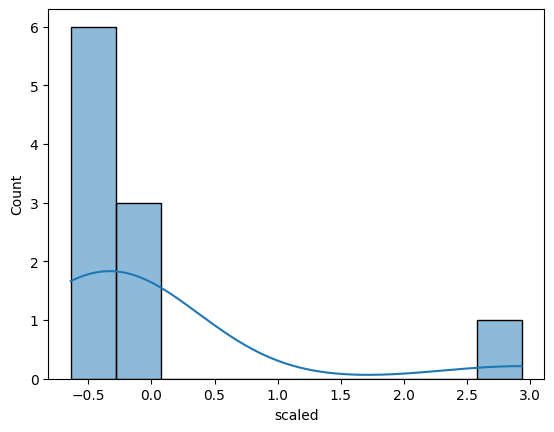

In [ ]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler

scaler=StandardScaler()
minmax=MinMaxScaler()

df1['scaled']=scaler.fit_transform(df1[['Age']])
df1['min']=minmax.fit_transform(df1[['Age']])


sns.histplot(df1['scaled'],kde=True)

<Axes: xlabel='min', ylabel='Count'>

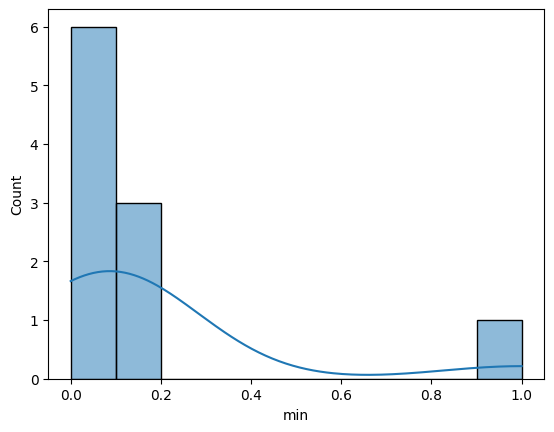

In [ ]:
sns.histplot(df1['min'],kde=True)

Lambda Value: -1.7690180978733812


<Axes: xlabel='boxcox', ylabel='Count'>

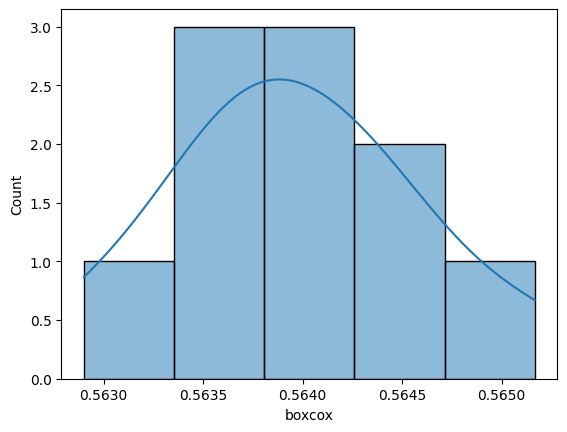

In [ ]:
from scipy.stats import boxcox

df1['boxcox'],lam = boxcox(df1['Age'])

print("Lambda Value:",lam)

sns.histplot(df1['boxcox'],kde=True)